In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/aii2023-conference-competition/sample_submission.csv
/kaggle/input/aii2023-conference-competition/train.csv
/kaggle/input/aii2023-conference-competition/test.csv
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/54660.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/61185.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/30414.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/62367.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/26831.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/4678.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/10386.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/12140.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/43013.bmp
/kaggle/input/aii2023-conference-competition/Train-Kaggle/Train-Kaggle/34692.bmp
/kaggle/input/a

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [3]:
df = pd.read_csv('/kaggle/input/aii2023-conference-competition/sample_submission.csv')
df.head()

,ID,Class Label
0,1.bmp,116
1,2.bmp,107
2,3.bmp,90
3,4.bmp,77
4,5.bmp,75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28080 entries, 0 to 28079
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           28080 non-null  object
 1   Class Label  28080 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 438.9+ KB


In [5]:
df.dtypes

ID             object
Class Label     int64
dtype: object

In [6]:
df.isnull().sum()/len(df)*100

ID             0.0
Class Label    0.0
dtype: float64

In [7]:
df.shape

(28080, 2)

In [8]:
df.infer_objects()

,ID,Class Label
0,1.bmp,116
1,2.bmp,107
2,3.bmp,90
3,4.bmp,77
4,5.bmp,75
...,...,...
28075,28076.bmp,123
28076,28077.bmp,143
28077,28078.bmp,140
28078,28079.bmp,22


<Axes: >

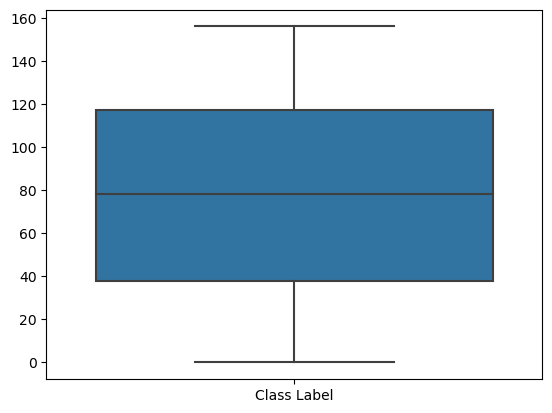

In [9]:
sns.boxplot(df)

<Axes: >

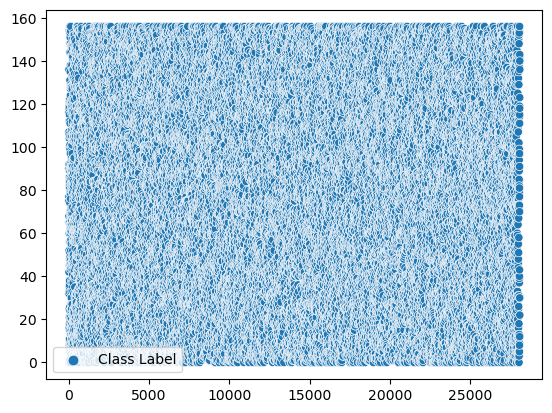

In [10]:
sns.scatterplot(df)

<Axes: >

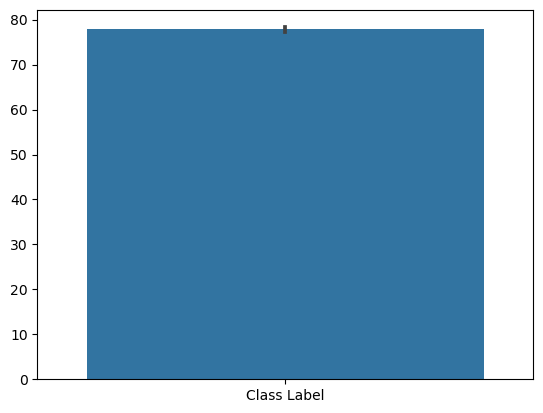

In [11]:
sns.barplot(df)

<Axes: >

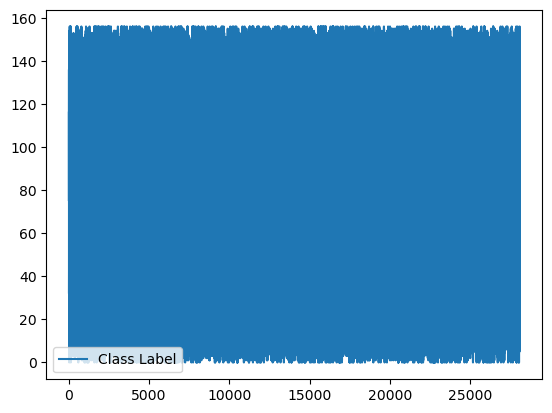

In [12]:
sns.lineplot(df)

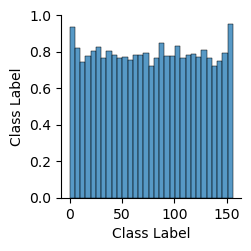

In [13]:
sns.pairplot(df)

<Axes: ylabel='Density'>

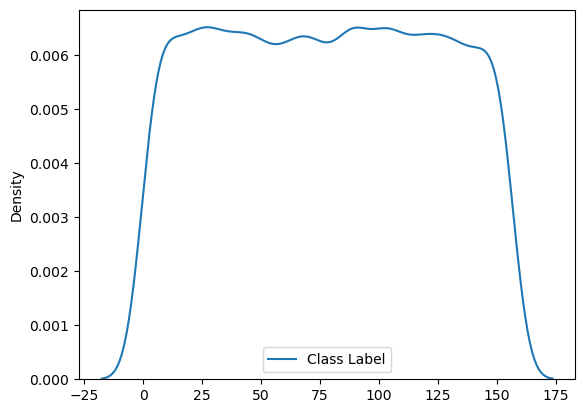

In [14]:
sns.kdeplot(df)

In [15]:
df.kurt()

/tmp/ipykernel_20/1257127604.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.kurt()


Class Label   -1.199904
dtype: float64

In [16]:
df.skew()

/tmp/ipykernel_20/1665899112.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew()


Class Label    0.003383
dtype: float64

/tmp/ipykernel_20/4277794465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True)


<Axes: >

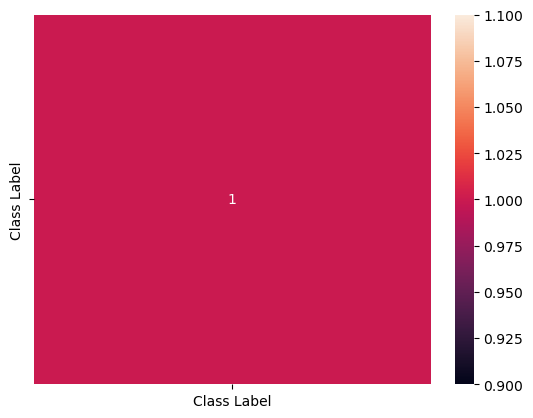

In [17]:
sns.heatmap(df.corr(),annot=True)

In [18]:
Q1 = df.quantile(0.25)
Q2 = df.quantile(0.5)
Q3 = df.quantile(0.75)
IQR=Q3-Q1
print(IQR)

Class Label    79.0
dtype: float64


/tmp/ipykernel_20/151362466.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = df.quantile(0.25)
/tmp/ipykernel_20/151362466.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = df.quantile(0.5)
/tmp/ipykernel_20/151362466.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = df.quantile(0.75)


In [19]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [20]:
df_new = df[~((df<UL)|(df>LL)).any(axis=1)]

/tmp/ipykernel_20/1882313045.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  df_new = df[~((df<UL)|(df>LL)).any(axis=1)]


In [21]:
df_new.shape

(0, 2)

<Axes: >

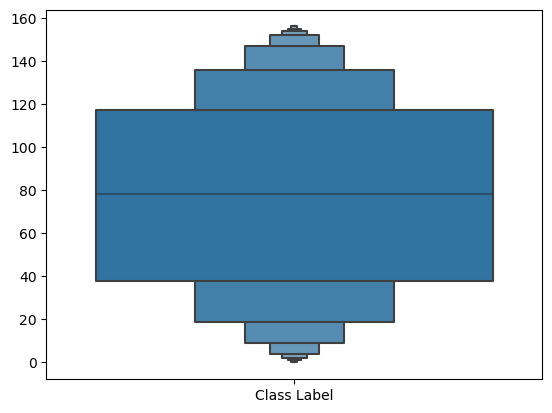

In [22]:
sns.boxenplot(df)

In [23]:
cat_cols = df.select_dtypes(include='object')

In [24]:
for i in cat_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

ID
1.bmp        1
18717.bmp    1
18728.bmp    1
18727.bmp    1
18726.bmp    1
            ..
9357.bmp     1
9356.bmp     1
9355.bmp     1
9354.bmp     1
28080.bmp    1
Name: ID, Length: 28080, dtype: int64
__________________________________________________


In [25]:
num_cols = df.select_dtypes(include='number')

In [26]:
for i in num_cols :
    print(i)
    print(df[i].value_counts())
    print('_'*50)

Class Label
9      220
90     216
30     215
156    214
104    211
      ... 
54     154
138    153
2      149
34     147
123    142
Name: Class Label, Length: 157, dtype: int64
__________________________________________________


In [27]:
df['Class Label']=df['Class Label'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_20/3130417409.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True,cmap='afmhot_r')
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


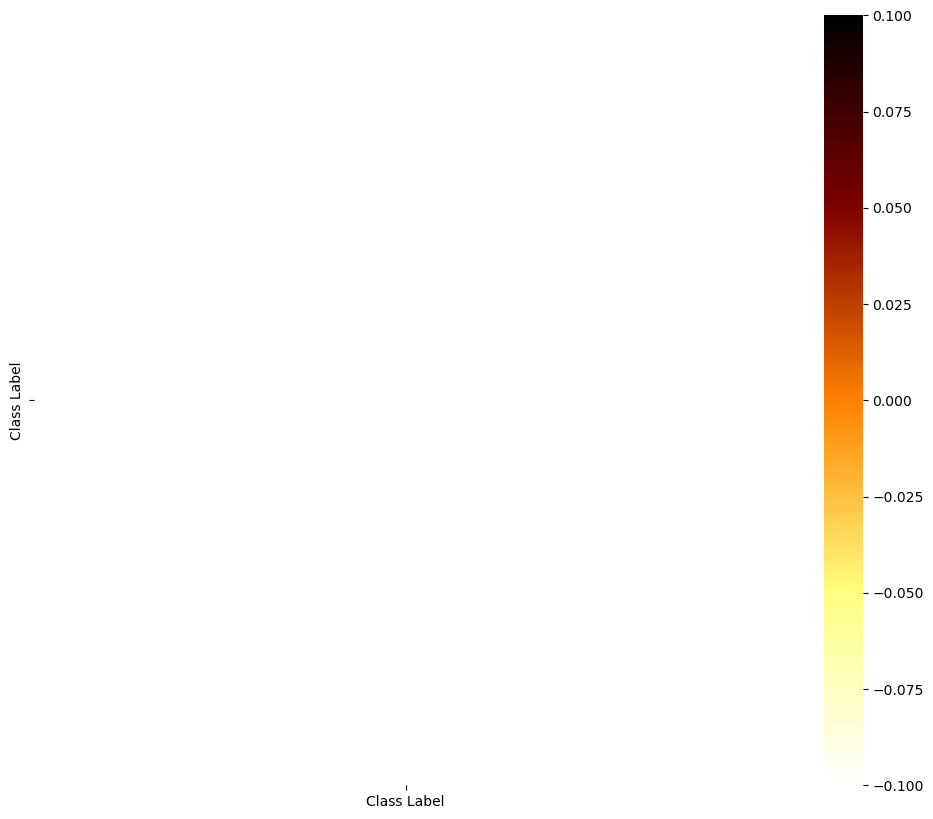

In [28]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='afmhot_r')
plt.show()

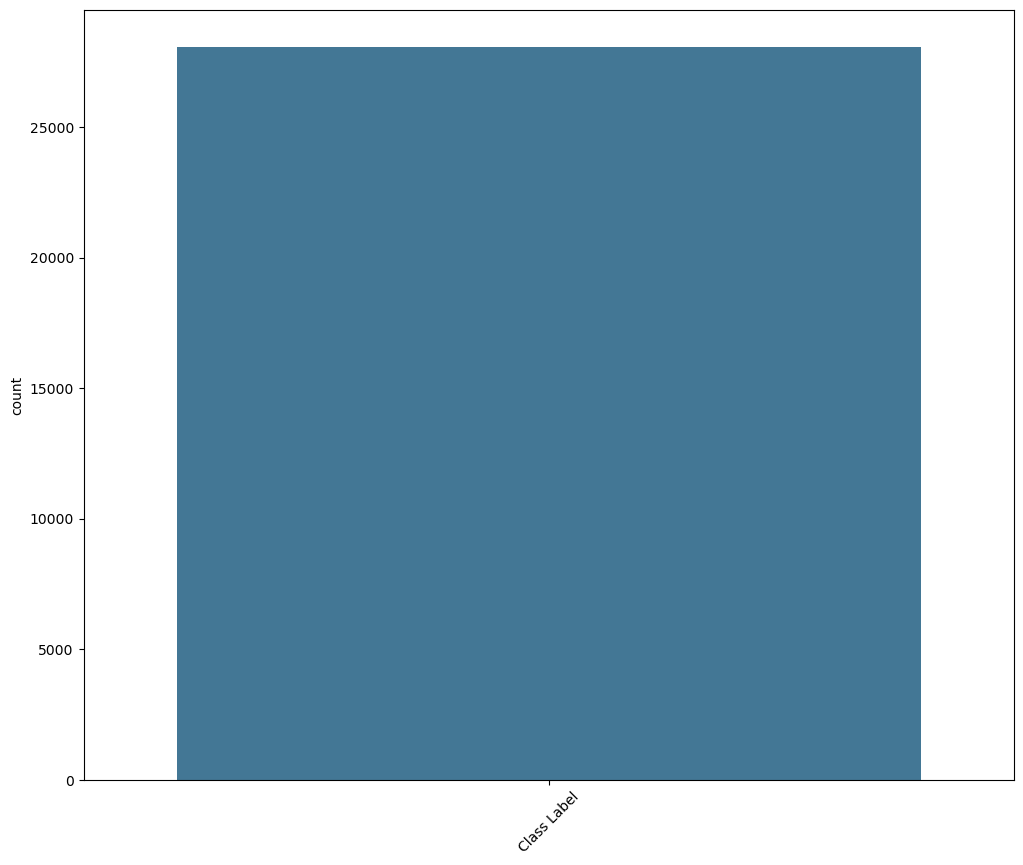

In [29]:
plt.figure(figsize=(12,10))
sns.countplot(df,palette='mako');
plt.xticks(rotation=45);

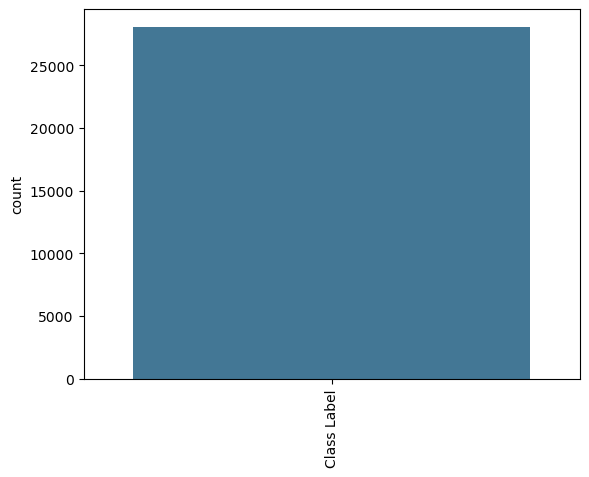

In [30]:
sns.countplot(df,palette='mako');
plt.xticks(rotation=90);

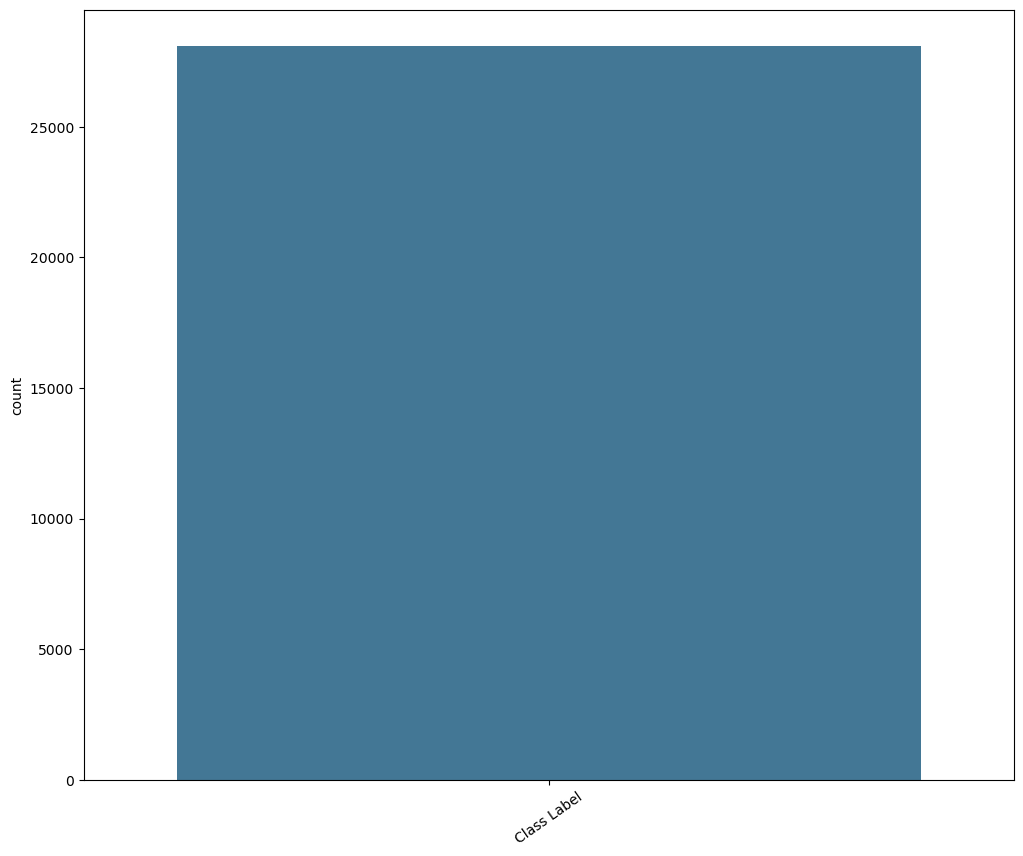

In [31]:
plt.figure(figsize=(12,10))
sns.countplot(df,palette='mako');
plt.xticks(rotation=35);

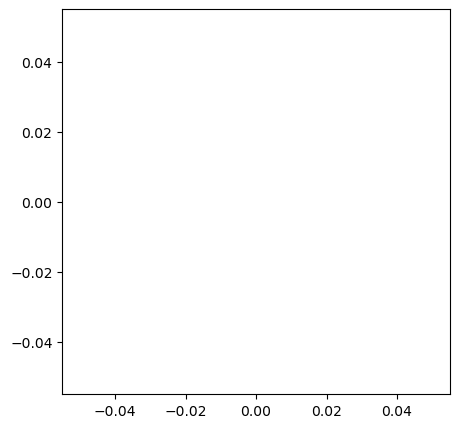

In [32]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=df,x=i,kde=True)
    print('\n')
    plt.show()

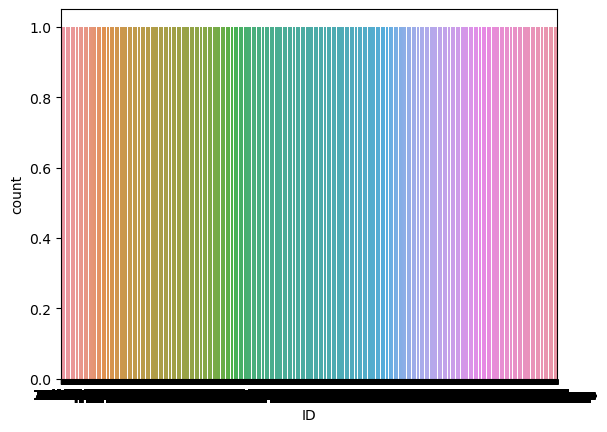

In [33]:
x=1
for i in cat_cols:
    sns.countplot(data=df,x=i)
    print('\n')
    plt.show()

In [34]:
df['Class Label'].value_counts()

Series([], Name: Class Label, dtype: int64)

In [35]:
df['Class Label'].unique()

array([nan])

In [36]:
df['Class Label'].isnull().sum()

28080